## Final Submission Notebook
# Unbreak my Seismic: A Geophysical Jigsaw Problem

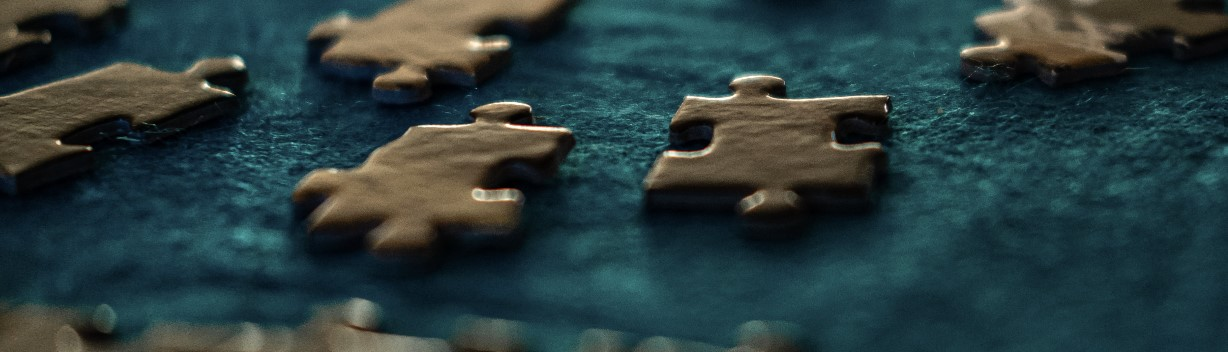

By Leo Dinendra March 19, 2024

----

### Part 0 - Getting Ready

First, let's install some required packages, import them, and set up the hold-out dataset file.

In [ ]:
!pip install -r requirements.txt

In [2]:
import matplotlib.pyplot as plt
import json
import mmap
import numpy as np
from scipy.ndimage import rotate
import pandas as pd
import ijson
import os
from tqdm import tqdm
from itertools import combinations
import json
from numba import jit
import statistics
from collections import Counter
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer, ConfusionMatrixDisplay

In [3]:
test_file = './test_patches.json' #REPLACE THIS WITH THE HIDDEN TEST DATA FILE

___

### Part 1 Data Exploration & Ideas

**Summary / TL;DR** : I am creating a solution for this challenge without the need for a GPU by pairing all possible puzzles and then calculating their Pearson product-moment correlation coefficients, Normalized Mean-Squared Error, and Possible-Gap. After that, I constructed a machine learning model to predict possible neighbors (F1 Score: ~0.96). Next, I reconstructed the possible neighbors with priority scores based on the average of correlation coefficients, Normalized Mean-Squared Error, and Possible-Gap.

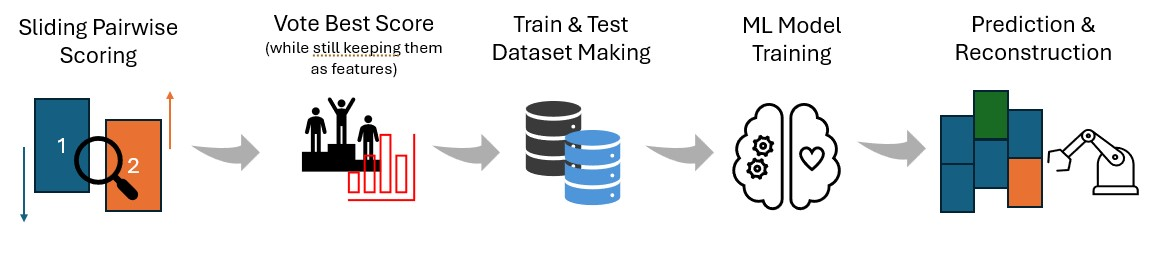

___

Let's explore the data first. As an example, we will use seismic key 20231207154336362023. Patch 0 and 15 which in the ground truth, is a known neighbour.

In [4]:
f = open('train.json')
for key, v in ijson.kvitems(f, ''):
    if key == '20231207154336362023':
        break

In [5]:
patch1 = np.array(v['patches']['0']['patch']).astype('float32')
x1 = v['coords']['0']['lu_corner']['x']
y1 = v['coords']['0']['lu_corner']['y']
deg1 = v['coords']['0']['rotation']
print(x1, y1, deg1) 

120 450 180


In [6]:
patch1.shape

(200, 120)

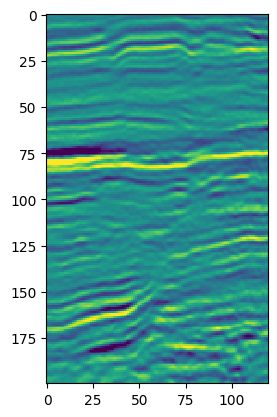

In [7]:
plt.imshow(np.rot90(np.rot90(patch1)), interpolation='none')
plt.show()

In [8]:
patch2 = np.array(v['patches']['15']['patch']).astype('float32')
x2 = v['coords']['15']['lu_corner']['x']
y2 = v['coords']['15']['lu_corner']['y']
deg2 = v['coords']['15']['rotation']
print(x2, y2, deg2) 

240 490 0


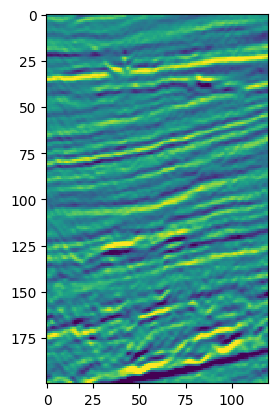

In [9]:
plt.imshow(patch2, interpolation='none')
plt.show()

In [10]:
trace1 = np.rot90(np.rot90(patch1))[:,-1]
trace2 = patch2[:,0]

It was the summer of 2023 in Australia. Onward released multiple interesting challenges, but here I am pursuing my master's degree, leaving my GPU back at home. How can I still participate?

Then it struck me to implement some ideas from the Parallel Perspective challenges. The idea goes like this: First, let's compare the trace with different methods of scoring for each gap between them. We slide through each pair of slices and save the maximum score. Below is an example animation from [WSU's RoboSub project](http://robosub.eecs.wsu.edu/wiki/ee/hydrophones/start). 

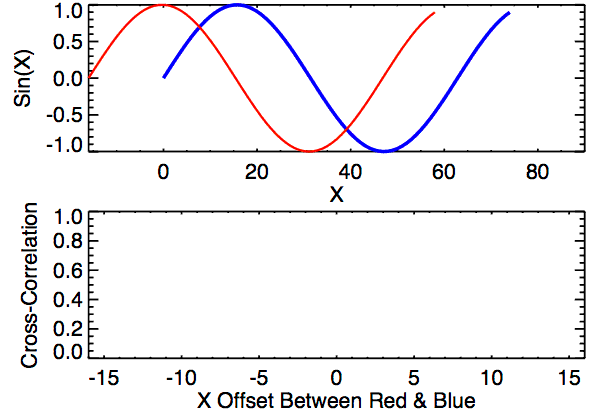

**HOWEVER**, the maximum/minimum score value does not always indicate the true position because each method has its own weaknesses, namely:

- Minimum Mean Squared Error only gives the minimum difference regardless of whether the signal shape/structure is different.
- Pearson Correlation only captures the similarity in signal shape, but it lacks accuracy when the amplitude of the signal is significantly different, meaning it's possible that it's not the true neighbor.
- All of these methods suffer when the gap is large (vertical distance between neighbouring patch).

Saving all of the calculation will store too much of a data, so every pair comparison only need one score from a specific gap.

Let's see an example on how I choose which gap:

In [11]:
@jit(nopython=True)
def corrcoeff_numba(x, y):
    # Compute correlation Pearson product-moment correlation coefficients
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    
    covariance = np.sum((x - x_mean) * (y - y_mean))
    correlation_coefficient = covariance / (len(x) * x_std * y_std)
    
    return correlation_coefficient

In [12]:
@jit(nopython=True)
def np_mse(signal1, signal2):
    """
    Calculate the Mean Squared Error (also normalized one) between signals
    """
    # Calculate squared differences
    squared_errors = np.square(signal1 - signal2)

    # Calculate Mean Squared Error (MSE)
    mse = np.mean(squared_errors)
    
    # Compute variance of signal1
    var_signal1 = np.var(signal1)
    
    # Check if var_signal1 is zero to avoid division by zero
    if var_signal1 == 0:
        # Handle the case when var_signal1 is zero
        nmse = np.inf if mse == 0 else np.nan
    else:
        # Compute NMSE
        nmse = 1 - (mse / var_signal1)
        
    return mse, nmse

In [13]:
def autocorr(x1, x2, length=20):
    #auto sliding correlate between 2 signal "x1" and "x2" with minimum variable "length" used
    
    pearson = np.array( [corrcoeff_numba(x1[-i:], x2[:i]) for i in range(length, len(x1))] + [corrcoeff_numba(x1, x2)] + [corrcoeff_numba(x1[:i], x2[-i:]) for i in range(len(x1), length, -1)])
    #mse, nmse = np.array( [np_mse(x1[-i:], x2[:i]) for i in range(length, len(x1))] + [np_mse(x1, x2)] + [np_mse(x1[:i], x2[-i:]) for i in range(len(x1), length, -1)])
    
    # Collecting mse and nmse values in a list
    mse_values = []
    nmse_values = []

    # Looping over the range
    for i in range(length, len(x1)):
        mse, nmse = np_mse(x1[-i:], x2[:i])
        mse_values.append(mse)
        nmse_values.append(nmse)

    # Adding the mse and nmse for the entire arrays
    mse_full, nmse_full = np_mse(x1, x2)
    mse_values.append(mse_full)
    nmse_values.append(nmse_full)

    # Looping in reverse
    for i in range(len(x1), length, -1):
        mse, nmse = np_mse(x1[:i], x2[-i:])
        mse_values.append(mse)
        nmse_values.append(nmse)

    # Converting lists to numpy arrays
    mse = np.array(mse_values)
    nmse = np.array(nmse_values)
    
    # Set NaN & infinity values to 0
    mse[np.isnan(mse)] = -1  
    mse[np.isinf(mse)] = -1
    nmse[np.isnan(nmse)] = -1  
    nmse[np.isinf(nmse)] = -1
    pearson[np.isnan(pearson)] = -1  
    pearson[np.isinf(pearson)] = -1
    
    return mse, nmse, pearson

In [14]:
mse, nmse, pearson = autocorr(trace2, trace1, length=20)

In [15]:
print('Min. Mean Squared Error =', np.min(mse),'; gap location =', np.argmin(mse))
print('Max. Normalized MSE =', np.max(nmse),'; gap location =', np.argmax(nmse))
print('Max. Pearson CorrCoef =', np.max(pearson),'; gap location =', np.argmax(pearson))

Min. Mean Squared Error = 56.230462646484376 ; gap location = 221
Max. Normalized MSE = 0.9558364963922164 ; gap location = 221
Max. Pearson CorrCoef = 0.9781415949689437 ; gap location = 221


Then use the following mechanism for voting which gap to choose : 

In [16]:
def voting(values):
    counts = Counter(values)
    majority_value = max(counts, key=counts.get)
    if counts[majority_value] > 1:  # If there is a majority value
        return majority_value
    else:  # If all values are unique choose one of the nearness
        average = sum(values) / len(values)
        closest_value = min(values, key=lambda x: abs(x - average))
        return closest_value

The idea is, if there are no major count, we vote the one which got the nearest neighbor.

In [17]:
gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
gap = voting([gap1, gap2, gap3])
print("gap choosen =", gap)

gap choosen = 41


Here as we can see, all of them agree on which is the gap point for their neighbour.

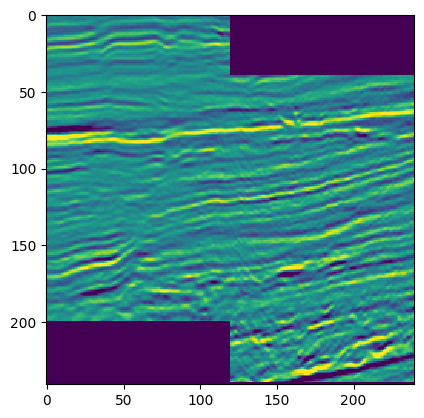

In [18]:
mergepatch = np.zeros([200+np.abs(gap), 120*2])

if int(deg1) == 180:
    patch1_used = np.rot90(np.rot90(patch1))
else:
    patch1_used = patch1
    
if int(deg2) == 180:
    patch2_used = np.rot90(np.rot90(patch2))
else:
    patch2_used = patch2
    
if gap>0:
    gapt=gap-1
    mergepatch[:200, :120] = patch1_used
    mergepatch[np.abs(gapt):np.abs(gapt)+200, 120:] = patch2_used
else:
    mergepatch[np.abs(gap):, :120] = patch1_used
    mergepatch[:200, 120:] = patch2_used
plt.imshow(mergepatch, interpolation='none')
plt.show()

It's a match!

Now Let's wrap the idea and make the datasets.

----

### Part 2 Dataset Making

Only 10 keys from the training data are needed because training all of them doesn't yield improvement and simply takes too long.

In [18]:
f = open('train.json')
keycount = 0
keytotal = 10
dataset = []
length = 20 
feature = ['key', 'anchor', 'anc_rotate', 'target', 'tgt_rotate']  + ['gap', 'gap_true','min_mse', 'max_pearson', 'max_nmse', 'connect']
for key, v in ijson.kvitems(f, ''):
    patches_list = list(v['coords'].keys())  # for test data list(v['patches'].keys()) 
    unique_pairs = list(combinations(patches_list, 2))
    for i,j in tqdm(unique_pairs, desc="Processing Seismic "+key, unit=" patch"):
        anc_patch = np.array(v['patches'][i]['patch']).astype('float32')
        anc_dat = anc_patch[:,-1]
        anc_dat_rot = np.flip(anc_patch[:,0])

        #if it's training dataset
        x_anc = v['coords'][i]['lu_corner']['x']
        y_anc = v['coords'][i]['lu_corner']['y']
        deg_anc = v['coords'][i]['rotation']
        if deg_anc == 180:
            deg_anc = 1
        else:
            deg_anc = 0    
            
        #if it's training dataset
        x_tgt = v['coords'][j]['lu_corner']['x']
        y_tgt = v['coords'][j]['lu_corner']['y']
        deg_tgt = v['coords'][j]['rotation']
        if deg_tgt == 180:
            deg_tgt = 1
        else:
            deg_tgt = 0  

        tgt_patch = np.array(v['patches'][j]['patch']).astype('float32')
        tgt_dat = tgt_patch[:,0]
        tgt_dat_rot = np.flip(tgt_patch[:,-1])

        #anc tgt
        mse, nmse, pearson = autocorr(anc_dat, tgt_dat, length)
        gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
        gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
        gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
        gap = voting([gap1, gap2, gap3])
        if gap > 0:
            gap=gap-1
            max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
            min_mse = mse[int(gap - ((len(mse)-1)/2))]
        elif gap == 0:
            max_pearson = pearson[int((len(pearson)-1)/2)]
            max_nmse = nmse[int((len(nmse)-1)/2)]
            min_mse = mse[int((len(mse)-1)/2)]         
        else:
            max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
            min_mse = mse[int(gap + ((len(mse)-1)/2))]

        connect = 0
        if (deg_anc==0) and (deg_tgt==0) and (x_tgt == x_anc+120) and (y_tgt < y_anc+200-length) and (y_tgt+200-length > y_anc):
            connect = 1
            gap_true = y_anc-y_tgt
        else:
            connect = 0
            gap_true = 999999

        data_input = [key, i, 0, j, 0] + [gap, gap_true, min_mse, max_pearson, max_nmse, connect]
        dataset.append(data_input)

        #anc_rot tgt
        mse, nmse, pearson = autocorr(anc_dat_rot, tgt_dat, length)
        gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
        gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
        gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
        gap = voting([gap1, gap2, gap3])
        if gap > 0:
            gap=gap-1
            max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
            min_mse = mse[int(gap - ((len(mse)-1)/2))]
        elif gap == 0:
            max_pearson = pearson[int((len(pearson)-1)/2)]
            max_nmse = nmse[int((len(nmse)-1)/2)]
            min_mse = mse[int((len(mse)-1)/2)]         
        else:
            max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
            min_mse = mse[int(gap + ((len(mse)-1)/2))]

        connect = 0
        if (deg_anc==1) and (deg_tgt==0) and (x_tgt == x_anc+120) and (y_tgt < y_anc+200-length) and (y_tgt+200-length > y_anc):
            connect = 1
            gap_true = y_anc-y_tgt
        else:
            connect = 0
            gap_true = 999999

        data_input = [key, i, 1, j, 0] + [gap, gap_true, min_mse, max_pearson, max_nmse, connect]
        dataset.append(data_input)

        #anc tgt_rot
        mse, nmse, pearson = autocorr(anc_dat, tgt_dat_rot, length)
        gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
        gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
        gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
        gap = voting([gap1, gap2, gap3])
        if gap > 0:
            gap=gap-1
            max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
            min_mse = mse[int(gap - ((len(mse)-1)/2))]
        elif gap == 0:
            max_pearson = pearson[int((len(pearson)-1)/2)]
            max_nmse = nmse[int((len(nmse)-1)/2)]
            min_mse = mse[int((len(mse)-1)/2)]         
        else:
            max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
            min_mse = mse[int(gap + ((len(mse)-1)/2))]

        connect = 0
        if (deg_anc==0) and (deg_tgt==1) and (x_tgt == x_anc+120) and (y_tgt < y_anc+200-length) and (y_tgt+200-length > y_anc):
            connect = 1
            gap_true = y_anc-y_tgt
        else:
            connect = 0
            gap_true = 999999

        data_input = [key, i, 0, j, 1] + [gap, gap_true, min_mse, max_pearson, max_nmse, connect]
        dataset.append(data_input)               

        #anc_rot tgt_rot
        mse, nmse, pearson = autocorr(anc_dat_rot, tgt_dat_rot, length)
        gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
        gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
        gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
        gap = voting([gap1, gap2, gap3])
        if gap > 0:
            gap=gap-1
            max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
            min_mse = mse[int(gap - ((len(mse)-1)/2))]
        elif gap == 0:
            max_pearson = pearson[int((len(pearson)-1)/2)]
            max_nmse = nmse[int((len(nmse)-1)/2)]
            min_mse = mse[int((len(mse)-1)/2)]         
        else:
            max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
            max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
            min_mse = mse[int(gap + ((len(mse)-1)/2))]

        connect = 0
        if (deg_anc==1) and (deg_tgt==1) and (x_tgt == x_anc+120) and (y_tgt < y_anc+200-length) and (y_tgt+200-length > y_anc):
            connect = 1
            gap_true = y_anc-y_tgt
        else:
            connect = 0
            gap_true = 999999

        data_input = [key, i, 1, j, 1] + [gap, gap_true, min_mse, max_pearson, max_nmse, connect]
        dataset.append(data_input) 
        #break
    keycount += 1
    if keycount == keytotal:
        break
traindatasetdf = pd.DataFrame(dataset, columns=feature)

Processing Seismic 20231207154337331389: 100%|███████████████████████████████████| 703/703 [00:41<00:00, 17.11 patch/s]


Here are the description of column:
- **key** : seismic key
- **anchor** : patch number that is used as anchor when doing pairwise comparison
- **anc_rotate** : anchor patch rotation
- **target** : patch number that is used as target when doing pairwise comparison
- **tgt_rotate** : target patch rotation
- **gap** : predicted gap that calculated from pairwise comparison scores
- **gap_true** : true gap that is calculated from training data 'coords' info 
- **min_mse** : minimum mean-squared error from predicted gap
- **max_pearson** : maximum pearson correlation coefficient from predicted gap
- **max_nmse** : maximum normalized mse from predicted gap
- **connect** : neighbor label from training data 'coords' info. 1 means connected.

Next, calculate the normalized gap and show the label 'connect' = 1 which means it's neighbour.

In [19]:
traindatasetdf['abs_gap'] = np.abs(traindatasetdf['gap'])

In [20]:
#save the dataset
traindatasetdf.to_csv('train_unbreak_dataset.csv', index=False)

In [21]:
traindatasetdf[traindatasetdf['connect']==1].sort_values(by=['abs_gap'], ascending=[True])

,key,anchor,anc_rotate,target,tgt_rotate,gap,gap_true,min_mse,max_pearson,max_nmse,connect,abs_gap
2181,20231207154333554738,33,1,35,0,-1,-1,251.518903,0.959657,0.919196,1,1
1944,20231207154333554738,25,0,41,0,-1,-1,73.544853,0.984840,0.969791,1,1
2293,20231207154333554738,18,1,14,0,-1,-1,322.743777,0.931138,0.862521,1,1
2403,20231207154333554738,24,1,29,1,-1,-1,488.896278,0.893867,0.789093,1,1
2507,20231207154333554738,26,1,21,1,-1,-1,650.457915,0.866642,0.745044,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1695,20231207154333554738,30,1,24,1,179,179,401.249860,0.904223,0.806434,1,179
1563,20231207154333554738,37,1,18,1,179,179,188.005069,0.985093,0.970087,1,179
1426,20231207154333554738,5,0,33,1,179,179,74.113339,0.991341,0.976300,1,179
1287,20231207154333554738,19,1,31,1,179,179,190.367199,0.863370,0.736629,1,179


As I stated before, the score fluctuates when the gap becomes large, making it not easily determined solely by stating the threshold of similarity score. That's why we will entrust it to machine learning by using the scores as features.

Now let's make the test dataset and put each test data key into **'testdf_raw'** folder.

In [22]:
folder_name = 'testdf_raw'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

In [25]:
f = open(test_file)
dataset = []
length = 20 
feature = ['key', 'anchor', 'anc_rotate', 'target', 'tgt_rotate']  + ['gap', 'min_mse', 'max_pearson', 'max_nmse']
for key, v in ijson.kvitems(f, ''):
    fname = './testdf_raw/' + key + '.csv'
    if not os.path.exists(fname):
        dataset = []
        patches_list = list(v['patches'].keys())  # for test data list(v['patches'].keys()) 
        unique_pairs = list(combinations(patches_list, 2))
        for i,j in tqdm(unique_pairs, desc="Processing Seismic "+key, unit=" patch"):
            anc_patch = np.array(v['patches'][i]['patch']).astype('float32')
            anc_dat = anc_patch[:,-1]
            anc_dat_rot = np.flip(anc_patch[:,0])

            tgt_patch = np.array(v['patches'][j]['patch']).astype('float32')
            tgt_dat = tgt_patch[:,0]
            tgt_dat_rot = np.flip(tgt_patch[:,-1])

            #anc tgt
            mse, nmse, pearson = autocorr(anc_dat, tgt_dat, length)
            gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
            gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
            gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
            gap = voting([gap1, gap2, gap3])
            if gap > 0:
                gap=gap-1
                max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
                min_mse = mse[int(gap - ((len(mse)-1)/2))]
            elif gap == 0:
                max_pearson = pearson[int((len(pearson)-1)/2)]
                max_nmse = nmse[int((len(nmse)-1)/2)]
                min_mse = mse[int((len(mse)-1)/2)]         
            else:
                max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
                min_mse = mse[int(gap + ((len(mse)-1)/2))]

            data_input = [key, i, 0, j, 0] + [gap, min_mse, max_pearson, max_nmse]
            dataset.append(data_input)

            #anc_rot tgt
            mse, nmse, pearson = autocorr(anc_dat_rot, tgt_dat, length)
            gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
            gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
            gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
            gap = voting([gap1, gap2, gap3])
            if gap > 0:
                gap=gap-1
                max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
                min_mse = mse[int(gap - ((len(mse)-1)/2))]
            elif gap == 0:
                max_pearson = pearson[int((len(pearson)-1)/2)]
                max_nmse = nmse[int((len(nmse)-1)/2)]
                min_mse = mse[int((len(mse)-1)/2)]         
            else:
                max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
                min_mse = mse[int(gap + ((len(mse)-1)/2))]

            data_input = [key, i, 1, j, 0] + [gap, min_mse, max_pearson, max_nmse]
            dataset.append(data_input)

            #anc tgt_rot
            mse, nmse, pearson = autocorr(anc_dat, tgt_dat_rot, length)
            gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
            gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
            gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
            gap = voting([gap1, gap2, gap3])
            if gap > 0:
                gap=gap-1
                max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
                min_mse = mse[int(gap - ((len(mse)-1)/2))]
            elif gap == 0:
                max_pearson = pearson[int((len(pearson)-1)/2)]
                max_nmse = nmse[int((len(nmse)-1)/2)]
                min_mse = mse[int((len(mse)-1)/2)]         
            else:
                max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
                min_mse = mse[int(gap + ((len(mse)-1)/2))]

            data_input = [key, i, 0, j, 1] + [gap, min_mse, max_pearson, max_nmse]
            dataset.append(data_input)               

            #anc_rot tgt_rot
            mse, nmse, pearson = autocorr(anc_dat_rot, tgt_dat_rot, length)
            gap1 = int(np.argmin(mse) - ((len(mse)-1)/2))
            gap2 = int(np.argmax(nmse) - ((len(nmse)-1)/2))
            gap3 = int(np.argmax(pearson) - ((len(pearson)-1)/2))
            gap = voting([gap1, gap2, gap3])
            if gap > 0:
                gap=gap-1
                max_pearson = pearson[int(gap - ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap - ((len(nmse)-1)/2))]
                min_mse = mse[int(gap - ((len(mse)-1)/2))]
            elif gap == 0:
                max_pearson = pearson[int((len(pearson)-1)/2)]
                max_nmse = nmse[int((len(nmse)-1)/2)]
                min_mse = mse[int((len(mse)-1)/2)]         
            else:
                max_pearson = pearson[int(gap + ((len(pearson)-1)/2))]
                max_nmse = nmse[int(gap + ((len(nmse)-1)/2))]
                min_mse = mse[int(gap + ((len(mse)-1)/2))]

            data_input = [key, i, 1, j, 1] + [gap, min_mse, max_pearson, max_nmse]
            dataset.append(data_input) 
        datasetdf = pd.DataFrame(dataset, columns=feature)
        datasetdf['abs_gap']=np.abs(datasetdf['gap'])
        datasetdf.to_csv(fname, index=False)

Processing Seismic 20231207154837919335: 100%|█████████████████████████████████| 3160/3160 [03:12<00:00, 16.41 patch/s]


----

### Part 3 Machine Learning Model Training

Loading training dataset

In [26]:
train_dataset = pd.read_csv('train_unbreak_dataset.csv')

In [27]:
train_dataset.head(5)

,key,anchor,anc_rotate,target,tgt_rotate,gap,gap_true,min_mse,max_pearson,max_nmse,connect,abs_gap
0,20231207154333554738,39,0,17,0,175,999999,1145.101484,0.440132,0.155937,0,175
1,20231207154333554738,39,1,17,0,177,999999,762.898522,0.568918,0.323663,0,177
2,20231207154333554738,39,0,17,1,132,999999,2326.482537,0.486563,0.223694,0,132
3,20231207154333554738,39,1,17,1,159,999999,984.901772,0.535331,0.138696,0,159
4,20231207154333554738,39,0,1,0,179,999999,1242.305618,0.510118,0.075484,0,179


In [28]:
#filling nan data with 0
train_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
train_dataset = train_dataset.fillna(0)

In [29]:
group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=83355)
length=20
featurelist = []
featurelist.append('abs_gap')
featurelist.append('min_mse')
featurelist.append('max_pearson')
featurelist.append('max_nmse')
for train_index, test_index in group_splitter.split(train_dataset[featurelist], train_dataset[['connect']], groups=train_dataset['key']):
    X_train, X_test = train_dataset[featurelist].iloc[train_index], train_dataset[featurelist].iloc[test_index]
    y_train, y_test = train_dataset['connect'].iloc[train_index], train_dataset['connect'].iloc[test_index]

and here's the feature that will be used..

In [30]:
featurelist

['abs_gap', 'min_mse', 'max_pearson', 'max_nmse']

Now let's train the model..

In [31]:
# Create and train the ML model
model = RandomForestClassifier(random_state=83355) #ExtraTreesClassifier(n_estimators=100, random_state=83355)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=83355)

In [32]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

#Uncomment below if you want to predict based on probability threshold
#threshold =0.7
#y_pred2 = (y_pred_prob[:,1] >= threshold).astype(int)

In [33]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9993131868131868
Precision: 0.968421052631579
Recall: 0.989247311827957
F1 Score: 0.9787234042553192


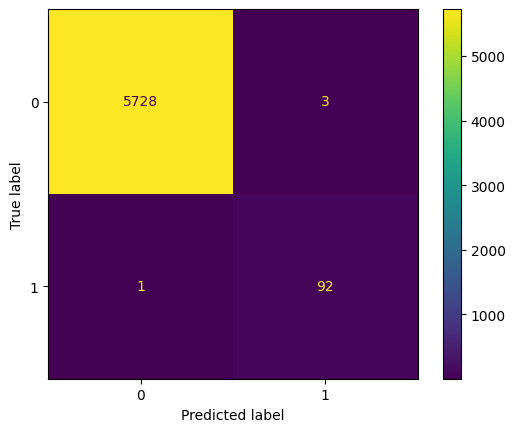

In [34]:
# Confusion Matrix
confusion_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=model.classes_)
disp.plot()
plt.show()

As we can see the model is doing well eventhough the data is highly imbalanced!

Now let's predict the test data..

----

### Part 4 Prediction & Reconstruction

Now let's load all test dataset from the folder, predict the data with our model and saving the results into folder called **'testdf_predicted'**

In [35]:
# Check if the folder exists
if os.path.exists('testdf_raw'): #check if source folder exists
    if not os.path.exists('testdf_predicted'):
        # If it doesn't exist, create it
        os.makedirs('testdf_predicted')

In [36]:
files = os.listdir('testdf_raw')
csv_files = [file for file in files if file.endswith('.csv')]
listfile = [os.path.join('./testdf_raw', file) for file in csv_files]

In [37]:
for i in tqdm(range(len(listfile))):
    fname_output = listfile[i].replace('testdf_raw','testdf_predicted')
    test_dataset = pd.read_csv(listfile[i])
    test_pred = model.predict(test_dataset[featurelist])
    test_predprob = model.predict_proba(test_dataset[featurelist])
    test_dataset['connect'] = test_pred
    test_dataset['connect_prob_0'] = test_predprob[:,0]
    test_dataset['connect_prob_1'] = test_predprob[:,1]
    test_dataset.to_csv(fname_output, index=False)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:32<00:00,  3.10it/s]


Now let's reconstruct the data based on our model prediction. The workflow is something like this:

1. Retrieve prediction data for a given key.
2. Select an anchor patch.
3. Identify potential neighboring patches.
4. Rank these potential neighbors based on a score, calculated as the average of the Pearson correlation coefficient, normalized mean squared error (MSE), and normalized predicted gap (you can also put weight on each score). Select the top-ranked candidate as the neighbor.
5. Incorporate the selected neighbor as an additional anchor patch. Repeat steps 3 through 4 until no candidates remain.

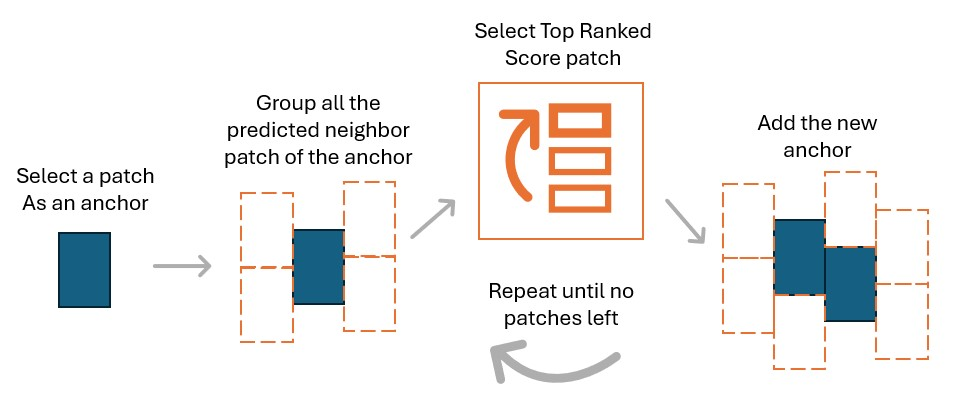

And that's it! By executing the remaining code below, a final submission file will be generated.

In [42]:
f = open(test_file)
folder_name = 'testdf_predicted'

files = os.listdir(folder_name)
csv_files = [file for file in files if file.endswith('.csv')]
listfile = [os.path.join('./'+folder_name, file) for file in csv_files]

progress_bar = tqdm(total=len(listfile), leave=False)

finalcords = pd.DataFrame()
patchx, patchz = 120, 200
coords = []
for key, v in ijson.kvitems(f, ''):

    prediction = pd.read_csv('./' + folder_name + '/' + str(key) + '.csv')
    prediction['abs_gap']=np.abs(prediction['gap'])
    prediction = prediction[prediction['connect']==1].sort_values(by=['abs_gap', 'max_pearson'], ascending=[True, False])    

    min_value = prediction['abs_gap'].min()
    max_value = prediction['abs_gap'].max()
    prediction['abs_gap_norm'] = (prediction['abs_gap'] - min_value) / (max_value - min_value)
    prediction['abs_gap_norm_reversed'] = 1 - prediction['abs_gap_norm']
    #prediction['score'] = (prediction['max_nmse'] + prediction['max_pearson'] + prediction['abs_gap_norm_reversed'])/3
    prediction['score'] = (prediction['max_nmse']*0.70 + prediction['max_pearson']*0.15 + prediction['abs_gap_norm_reversed']*0.15)

    #filter focused seismic lines
    pred = prediction[prediction['key'] == key]
    idp1 = str(pred['anchor'].iloc[0])
    idp2 = str(pred['target'].iloc[0])
    idp1_r = str(pred['anc_rotate'].iloc[0])
    idp2_r = str(pred['tgt_rotate'].iloc[0])
    gap = pred['gap'].iloc[0]
    idp_queue = list(map(str, np.arange(0, np.max([pred.anchor.max(), pred.target.max()])+1).tolist()))
    idp_used = []
    idp_queue.remove(idp1)
    idp_queue.remove(idp2)
    idp_used.append(idp1)
    idp_used.append(idp2)

    coords_df = pd.DataFrame(columns=['id', 'x', 'y', 'rotate'])
    coords_df.loc[len(coords_df)] = [idp1, 0, 0, idp1_r]
    idp_x = coords_df[coords_df['id']==idp1]['x'].values[0]
    idp_y = coords_df[coords_df['id']==idp1]['y'].values[0]
    coords_df.loc[len(coords_df)] = [idp2, idp_x+patchx, idp_y+(gap*-1), idp2_r]

    while idp_queue:
        collection = pd.DataFrame()
        for i in range(len(coords_df)):
            collect1 = pred[pred['anchor']==int(coords_df.iloc[i,0])]
            collect2 = pred[pred['target']==int(coords_df.iloc[i,0])]
            collection = pd.concat([collection, collect1], ignore_index=True)
            collection = pd.concat([collection, collect2], ignore_index=True)
            
        collection.sort_values(by=['score'], ascending=[False], inplace=True)
        
        for i in range(len(collection)):
            idfound = 0
            id_newanc = False
            id_newtgt = False
            id_anc = 999
            id_tgt = 999
            rot_anc = 999
            rot_tgt = 999
            gap = 999
            if str(collection['anchor'].iloc[i]) not in idp_used:
                if str(collection['target'].iloc[i]) in idp_used:
                    idfound = 1
                    #print(i, 1, collection['anchor'].iloc[i], collection['target'].iloc[i])
                    id_anc = collection['anchor'].iloc[i]
                    id_tgt = collection['target'].iloc[i]
                    rot_anc = collection['anc_rotate'].iloc[i]
                    rot_tgt = collection['tgt_rotate'].iloc[i]
                    gap = collection['gap'].iloc[i]
                    idp_used.append(str(collection.iloc[i,1]))
                    idp_queue.remove(str(collection.iloc[i,1]))
                    id_newanc = True
                    break

            elif str(collection['target'].iloc[i]) not in idp_used:
                if str(collection['anchor'].iloc[i]) in idp_used:
                    idfound = 1
                    #print(i, 2, collection['anchor'].iloc[i], collection['target'].iloc[i])
                    id_anc = collection['anchor'].iloc[i]
                    id_tgt = collection['target'].iloc[i]
                    rot_anc = collection['anc_rotate'].iloc[i]
                    rot_tgt = collection['tgt_rotate'].iloc[i]
                    gap = collection['gap'].iloc[i]
                    idp_used.append(str(collection.iloc[i,3]))
                    idp_queue.remove(str(collection.iloc[i,3]))
                    id_newtgt = True
                    break
        if id_newanc:
            idp_x = coords_df[coords_df['id']==str(id_tgt)]['x'].values[0]
            idp_y = coords_df[coords_df['id']==str(id_tgt)]['y'].values[0]
            idp_rot = coords_df[coords_df['id']==str(id_tgt)]['rotate'].values[0]

            if int(idp_rot) == 1:
                if rot_anc == 0:
                    if rot_tgt == 0: #check

                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1)
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: #check

                        #print('check! 1')
                        curr_x = idp_x - patchx
                        curr_y = idp_y + gap  
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
                elif rot_anc == 1:
                    if rot_tgt == 0: #checked
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1)
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: #checked
                        curr_x = idp_x - patchx
                        curr_y = idp_y + gap  
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
            elif int(idp_rot) == 0:
                if rot_anc == 0:
                    if rot_tgt == 0: #checked
                        #print('check! 2')
                        curr_x = idp_x - patchx
                        curr_y = idp_y + (gap)
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: #checked
                        #print('check! 3')
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1)  
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
                elif rot_anc == 1:
                    if rot_tgt == 0: #checked
                        curr_x = idp_x - patchx
                        curr_y = idp_y + gap
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: #checked
                        #print('check! 4')
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1)   
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_anc), curr_x, curr_y, curr_rot]                  

        if id_newtgt:
            idp_x = coords_df[coords_df['id']==str(id_anc)]['x'].values[0]
            idp_y = coords_df[coords_df['id']==str(id_anc)]['y'].values[0]
            idp_rot = coords_df[coords_df['id']==str(id_anc)]['rotate'].values[0]

            if int(idp_rot) == 1:
                if rot_anc == 0:
                    if rot_tgt == 0: #checked
                        #print('check! 5')
                        curr_x = idp_x - patchx
                        curr_y = idp_y + (gap)
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: #checked
                        curr_x = idp_x - patchx
                        curr_y = idp_y + gap  
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  
                elif rot_anc == 1:
                    if rot_tgt == 0: #checked
                        #print('check! 7')
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1)
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: #checked
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1)  
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  

            elif int(idp_rot) == 0:           
                if rot_anc == 0:
                    if rot_tgt == 0: # check
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1) 
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1:  # check
                        curr_x = idp_x + patchx
                        curr_y = idp_y + (gap*-1) 
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  
                elif rot_anc == 1:
                    if rot_tgt == 0: # check
                        curr_x = idp_x - patchx
                        curr_y = idp_y + (gap)
                        curr_rot = '1'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]  
                    elif rot_tgt == 1: # check
                        #print('check! 9')
                        curr_x = idp_x - patchx
                        curr_y = idp_y + gap  
                        curr_rot = '0'
                        coords_df.loc[len(coords_df)] = [str(id_tgt), curr_x, curr_y, curr_rot]         
        #coordinate postprocessing
    coords_df['x_scaled'] = coords_df['x'] + np.abs(coords_df['x'].min())
    coords_df['y_scaled'] = coords_df['y'] + np.abs(coords_df['y'].min())
    coords_df['key'] = key

    patch = np.array(v['patches']['0']['patch']).astype('float32')
    height, width = patch.shape  
    img_width = coords_df['x_scaled'].max()+width
    img_height = coords_df['y_scaled'].max()+height
    shuffled_array = np.zeros((img_height, img_width))
    for i in list(map(int, list(coords_df['id'].values))):   
        patch = np.array(v['patches'][coords_df.iloc[i,0]]['patch']).astype('float32')
        if coords_df.iloc[i,3] == '1':
            patch=np.rot90(np.rot90(patch))
        posx, posy = coords_df.iloc[i,4], coords_df.iloc[i,5]
        shuffled_array[posy:posy + height, posx:posx + width] = patch      

    #if you want to save the reconstructed image, uncomment below
    #fname_pic = './constructed_image/'+str(key)+'.png'
    #plt.imsave(fname_pic, shuffled_array)

    finalcords = pd.concat([finalcords, coords_df], ignore_index=True)
    progress_bar.update(1)
    
progress_bar.close()

In [43]:
finalcords.head(5)

,id,x,y,rotate,x_scaled,y_scaled,key
0,69,0,0,0,960,221,20231207154753507821
1,82,120,4,1,1080,225,20231207154753507821
2,11,240,35,0,1200,256,20231207154753507821
3,20,360,15,0,1320,236,20231207154753507821
4,22,480,-19,0,1440,202,20231207154753507821


.. and at last, saving the result into submission format called **'submission.json'**.

In [44]:
solution_json = {}   
results = finalcords
keys = results['key'].unique().tolist()
for key in keys:  
    datakey = results[results['key']==key].sort_values(by=['x_scaled', 'y_scaled'], ascending=[True, True]) 
    list_coords = []
    indices = datakey['id'].tolist()
    indices = list(map(str, indices))
    for ids in indices:
        
        posx = datakey[datakey["id"]==ids]['x_scaled'].values[0]   #your value of posx for current patch
        posy = datakey[datakey["id"]==ids]['y_scaled'].values[0]   #your value of posy for current patch 
        
        rot = datakey[datakey["id"]==ids]['rotate'].values[0]
        rotate = "nan"
        if rot == "1":
            rotate = "180"
        else:
            rotate = "0"
        angle = rotate  # your value of angle for current patch
        
        list_coords.append({ 
            'lu_corner': {'x': int(posx),'y': int(posy) },
            'rotation': int(angle) 
            })

    coords_dict = dict(zip(indices, list_coords))

    solution_json[key] = {
                'coords': coords_dict,
              }

In [45]:
with open('submission.json', 'w', encoding="utf-8") as f:
        json.dump(solution_json, f)

----